In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("data/Online Retail.xlsx")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()
print("-----")
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
-----
            Quantity                 InvoiceDate      UnitPrice     CustomerID
count  541909.000000                      541909  541909.000000  406829.000000
mean        9.552250  2011-07-04 13:34:57.156386       4.611114   15287.690570
min    -80995.000000         2010-12-01 08:26:00  -11062.060000   12

In [5]:
print("Missing values:")
print(df.isnull().sum())
print("-----")
print("Duplicate rows:", df.duplicated().sum())
print("Cancelled invoices (start with C):", df['InvoiceNo'].astype(str).str.startswith('C').sum())
print("Negative quantity rows:", (df['Quantity'] < 0).sum())
print("Zero or negative price rows:", (df['UnitPrice'] <= 0).sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
-----
Duplicate rows: 5268
Cancelled invoices (start with C): 9288
Negative quantity rows: 10624
Zero or negative price rows: 2517


In [6]:
# 1. Remove exact duplicate rows
df_clean = df.drop_duplicates().copy()
print("After removing duplicates:", df_clean.shape)

# 2. Cancelled orders (InvoiceNo starts with C) kept separately for return analysis
is_cancel = df_clean['InvoiceNo'].astype(str).str.startswith('C')
df_returns = df_clean[is_cancel].copy()
df_clean = df_clean[~is_cancel].copy()
print("Cancelled rows moved to df_returns:", df_returns.shape[0])

# 3. Remove rows with zero/negative price or quantity (bad entries/adjustments)
df_clean = df_clean[(df_clean['UnitPrice'] > 0) & (df_clean['Quantity'] > 0)].copy()
print("After removing invalid price/quantity:", df_clean.shape)

After removing duplicates: (536641, 8)
Cancelled rows moved to df_returns: 9251
After removing invalid price/quantity: (524878, 8)


In [7]:
# 4. Remove rows with missing Description (product name unknown)
df_clean = df_clean.dropna(subset=['Description']).copy()
df_clean['Description'] = df_clean['Description'].str.strip()

# 5. CustomerID: keep the rows (they are real sales) but flag them,
#    because customer-level analysis can only use rows with a CustomerID
df_clean['HasCustomer'] = df_clean['CustomerID'].notna()

# 6. New columns for analysis
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['Year'] = df_clean['InvoiceDate'].dt.year
df_clean['Month'] = df_clean['InvoiceDate'].dt.month
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

print("Final shape:", df_clean.shape)
print("Missing CustomerID rows:", (~df_clean['HasCustomer']).sum())
print(df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].describe())

Final shape: (524878, 15)
Missing CustomerID rows: 132186
            Quantity      UnitPrice    TotalAmount
count  524878.000000  524878.000000  524878.000000
mean       10.616600       3.922573      20.275399
std       156.280031      36.093028     271.693566
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       3.900000
50%         4.000000       2.080000       9.920000
75%        11.000000       4.130000      17.700000
max     80995.000000   13541.330000  168469.600000


       Quantity   UnitPrice   TotalAmount
0.500       4.0      2.0800       9.92000
0.950      30.0      9.9500      59.80000
0.990     100.0     16.9800     183.60000
0.999     456.0    165.0246     841.21059
1.000   80995.0  13541.3300  168469.60000


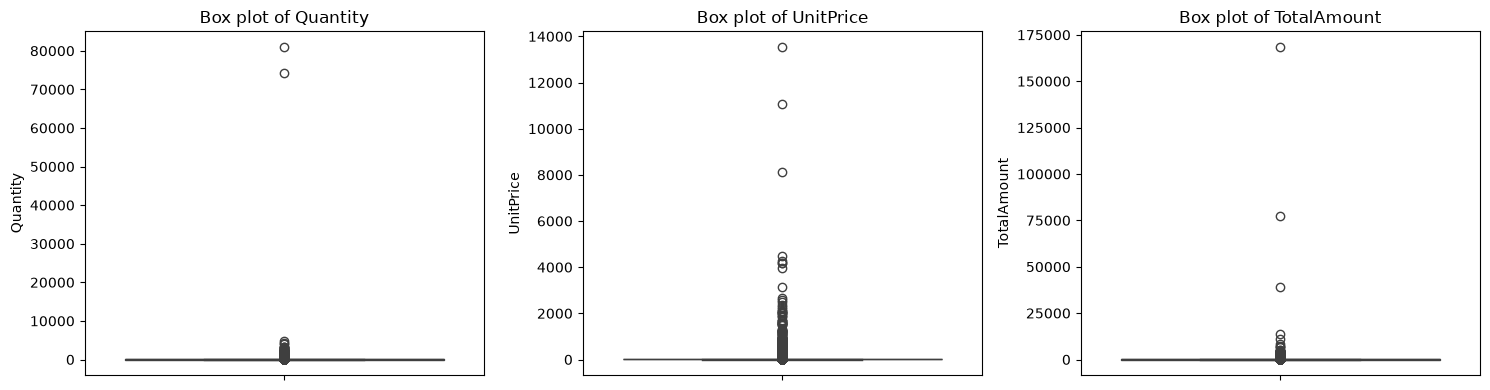

In [8]:
print(df_clean[['Quantity', 'UnitPrice', 'TotalAmount']].quantile([0.5, 0.95, 0.99, 0.999, 1.0]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'TotalAmount']):
    sns.boxplot(y=df_clean[col], ax=ax)
    ax.set_title(f"Box plot of {col}")
plt.tight_layout()
plt.show()

In [9]:
# Real products have StockCode starting with 5 digits (e.g. 85123A). Others are postage, fees, adjustments etc.
is_product = df_clean['StockCode'].astype(str).str.match(r'^\d{5}')
non_product = df_clean[~is_product]

print("Non-product rows:", len(non_product))
print(non_product.groupby('StockCode')['TotalAmount'].agg(['count', 'sum']).sort_values('count', ascending=False).head(10))

df_clean = df_clean[is_product].copy()
print("\nFinal rows after cleaning:", df_clean.shape[0])
print("Total revenue:", round(df_clean['TotalAmount'].sum(), 2))
print("Max Quantity:", df_clean['Quantity'].max(), "| Max UnitPrice:", df_clean['UnitPrice'].max())

Non-product rows: 2374
              count         sum
StockCode                      
POST           1126   78101.880
DOT             706  206248.770
M               316   77750.270
C2              141    7051.000
DCGSSGIRL        13     144.430
BANK CHARGES     12     165.001
DCGSSBOY         11     150.550
gift_0001_20      9     167.050
gift_0001_10      8      74.970
gift_0001_30      7     175.530

Final rows after cleaning: 522504
Total revenue: 10246820.87
Max Quantity: 80995 | Max UnitPrice: 649.5


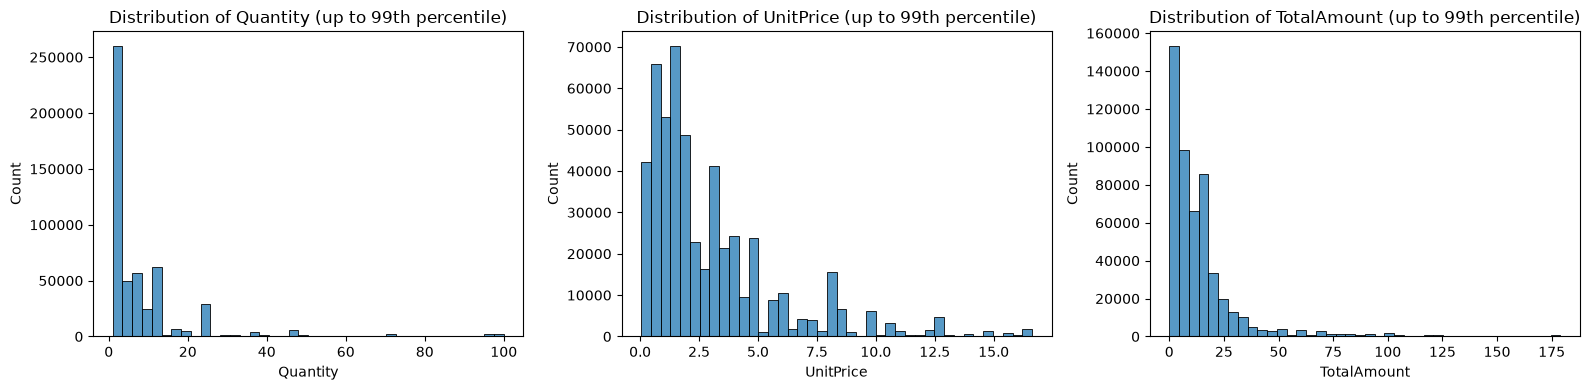

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['Quantity', 'UnitPrice', 'TotalAmount']):
    cap = df_clean[col].quantile(0.99)
    sns.histplot(df_clean[df_clean[col] <= cap][col], bins=40, ax=ax)
    ax.set_title(f"Distribution of {col} (up to 99th percentile)")
plt.tight_layout()
plt.show()

In [11]:
big = df_clean[df_clean['Quantity'] > 10000][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'TotalAmount', 'CustomerID']]
print(big)

# Did the same customer cancel the same product later?
for _, r in big.iterrows():
    match = df_returns[(df_returns['StockCode'] == r['StockCode']) & (df_returns['Quantity'] == -r['Quantity'])]
    print(r['InvoiceNo'], "-> cancelled counterpart found:", len(match) > 0)

       InvoiceNo StockCode                     Description  Quantity  \
61619     541431     23166  MEDIUM CERAMIC TOP STORAGE JAR     74215   
540421    581483     23843     PAPER CRAFT , LITTLE BIRDIE     80995   

        UnitPrice  TotalAmount  CustomerID  
61619        1.04      77183.6     12346.0  
540421       2.08     168469.6     16446.0  
541431 -> cancelled counterpart found: True
581483 -> cancelled counterpart found: True


In [12]:
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).isin(['541431', '581483'])].copy()

print("Final rows:", df_clean.shape[0])
print("Total revenue:", round(df_clean['TotalAmount'].sum(), 2))
print("Max Quantity:", df_clean['Quantity'].max())
print("Unique customers (with ID):", df_clean['CustomerID'].nunique())
print("Unique invoices:", df_clean['InvoiceNo'].nunique())
print("Unique products:", df_clean['StockCode'].nunique())
print("Countries:", df_clean['Country'].nunique())

Final rows: 522502
Total revenue: 10001167.67
Max Quantity: 4800
Unique customers (with ID): 4333
Unique invoices: 19771
Unique products: 3899
Countries: 38


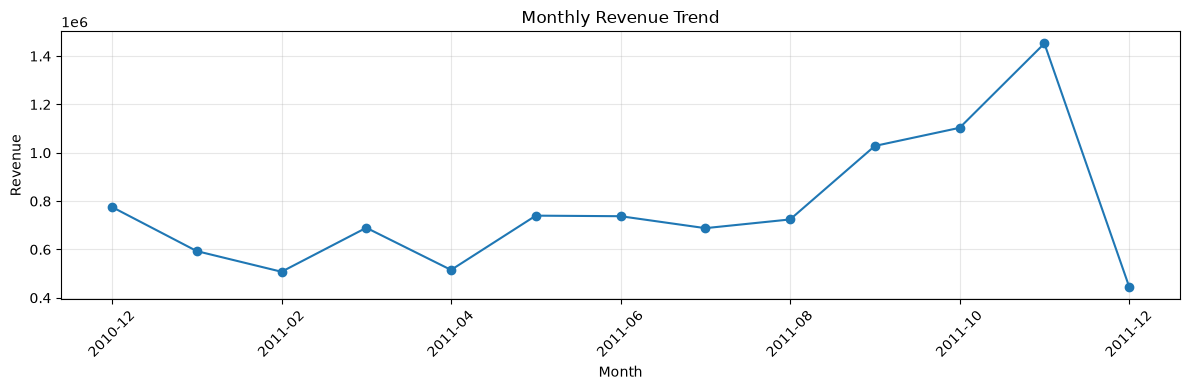

YearMonth
2011-11    1452113.0
2011-10    1103311.0
2011-09    1028314.0
Name: TotalAmount, dtype: float64
YearMonth
2011-12    446018.0
2011-02    507783.0
2011-04    515355.0
Name: TotalAmount, dtype: float64


In [13]:
monthly = df_clean.groupby('YearMonth')['TotalAmount'].sum()

plt.figure(figsize=(12, 4))
monthly.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(monthly.round(0).sort_values(ascending=False).head(3))
print(monthly.round(0).sort_values().head(3))

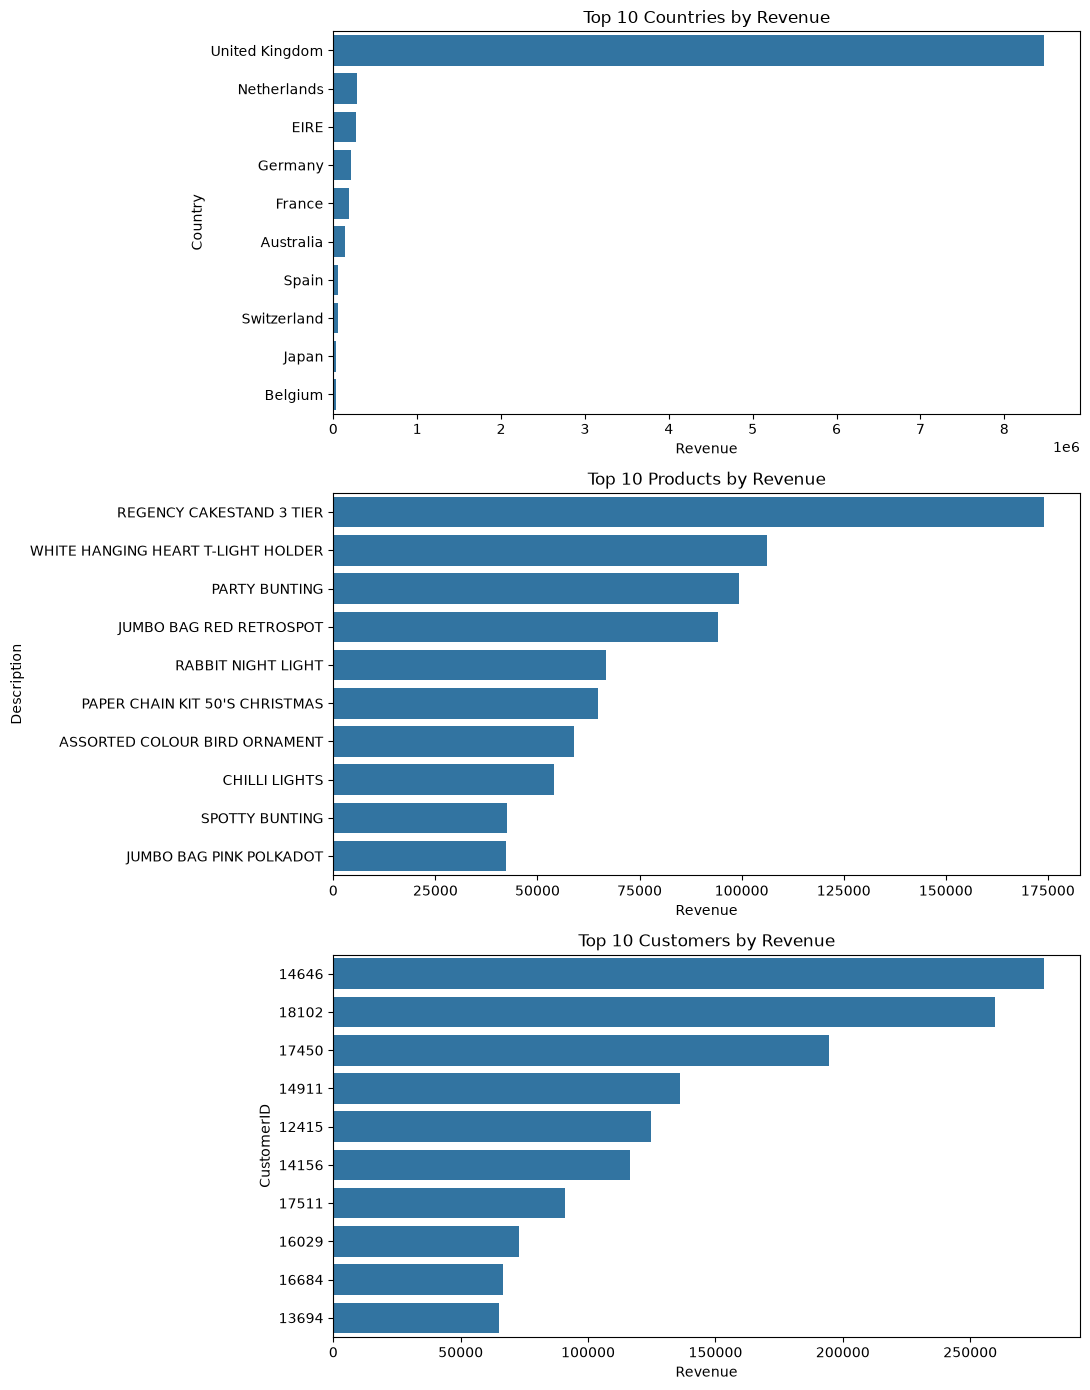

Country
United Kingdom    8478392.0
Netherlands        283889.0
EIRE               270851.0
Germany            205381.0
France             184493.0
Australia          138104.0
Spain               55707.0
Switzerland         53066.0
Japan               37416.0
Belgium             36927.0
Name: TotalAmount, dtype: float64
Country
United Kingdom    84.8
Netherlands        2.8
EIRE               2.7
Germany            2.1
France             1.8
Australia          1.4
Spain              0.6
Switzerland        0.5
Japan              0.4
Belgium            0.4
Name: TotalAmount, dtype: float64


In [14]:
fig, axes = plt.subplots(3, 1, figsize=(11, 14))

top_countries = df_clean.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, ax=axes[0])
axes[0].set_title("Top 10 Countries by Revenue")
axes[0].set_xlabel("Revenue")

top_products = df_clean.groupby('Description')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_products.values, y=top_products.index, ax=axes[1])
axes[1].set_title("Top 10 Products by Revenue")
axes[1].set_xlabel("Revenue")

top_customers = df_clean.dropna(subset=['CustomerID']).groupby('CustomerID')['TotalAmount'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=top_customers.values, y=top_customers.index.astype(int).astype(str), ax=axes[2])
axes[2].set_title("Top 10 Customers by Revenue")
axes[2].set_xlabel("Revenue")

plt.tight_layout()
plt.show()

print(top_countries.round(0))
print((100 * top_countries / df_clean['TotalAmount'].sum()).round(1))

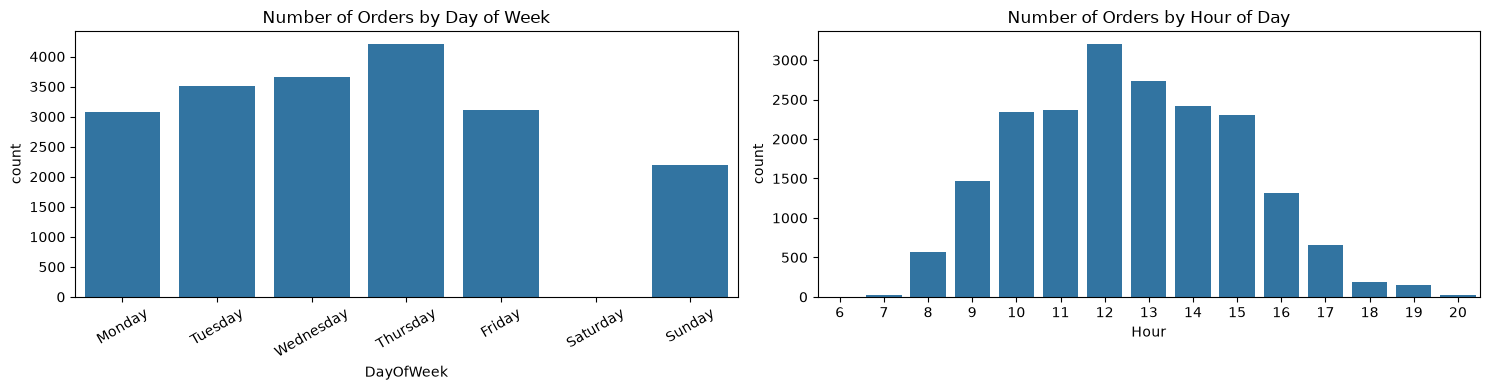

DayOfWeek
Thursday     4209
Wednesday    3667
Tuesday      3508
Friday       3108
Monday       3076
Sunday       2203
Name: count, dtype: int64
Hour
12    3204
13    2730
14    2419
Name: count, dtype: int64


In [15]:
invoices = df_clean.drop_duplicates('InvoiceNo')

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.countplot(data=invoices, x='DayOfWeek', order=day_order, ax=axes[0])
axes[0].set_title("Number of Orders by Day of Week")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=invoices, x='Hour', ax=axes[1])
axes[1].set_title("Number of Orders by Hour of Day")

plt.tight_layout()
plt.show()

print(invoices['DayOfWeek'].value_counts())
print(invoices['Hour'].value_counts().head(3))

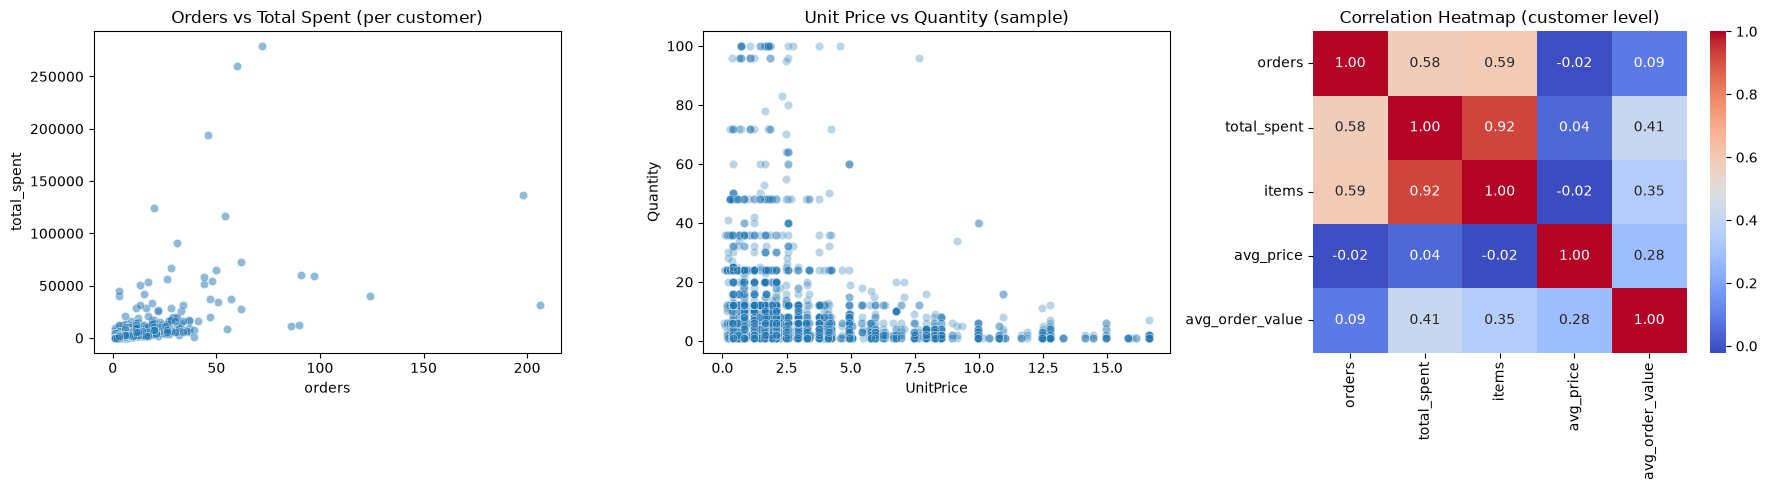

Correlation orders vs total_spent: 0.58
Top 20% customers share of revenue (with ID): 73.9 %


In [16]:
cust = df_clean.dropna(subset=['CustomerID']).groupby('CustomerID').agg(
    orders=('InvoiceNo', 'nunique'),
    total_spent=('TotalAmount', 'sum'),
    items=('Quantity', 'sum'),
    avg_price=('UnitPrice', 'mean')
)
cust['avg_order_value'] = cust['total_spent'] / cust['orders']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=cust, x='orders', y='total_spent', alpha=0.5, ax=axes[0])
axes[0].set_title("Orders vs Total Spent (per customer)")

sample = df_clean[(df_clean['Quantity'] <= df_clean['Quantity'].quantile(0.99)) &
                  (df_clean['UnitPrice'] <= df_clean['UnitPrice'].quantile(0.99))].sample(5000, random_state=1)
sns.scatterplot(data=sample, x='UnitPrice', y='Quantity', alpha=0.3, ax=axes[1])
axes[1].set_title("Unit Price vs Quantity (sample)")

sns.heatmap(cust.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=axes[2])
axes[2].set_title("Correlation Heatmap (customer level)")

plt.tight_layout()
plt.show()

print("Correlation orders vs total_spent:", round(cust['orders'].corr(cust['total_spent']), 2))
n20 = int(0.2 * len(cust))
share = cust['total_spent'].sort_values(ascending=False).head(n20).sum() / cust['total_spent'].sum()
print("Top 20% customers share of revenue (with ID):", round(100 * share, 1), "%")

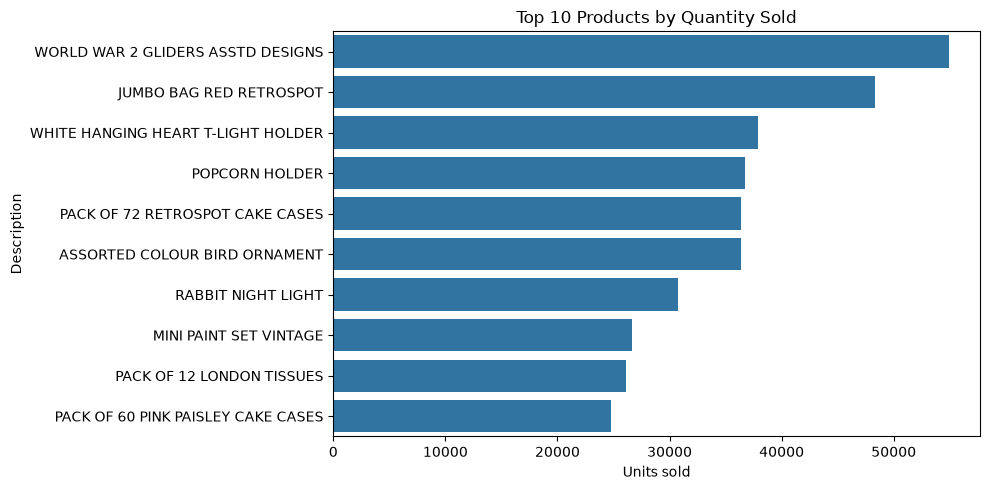

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
Name: Quantity, dtype: int64
Average order value: 505.85 | Median: 302.2
Cancelled invoices: 3836 of 25900 = 14.81 %


In [17]:
# Q4: products with highest quantity sold
top_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_qty.values, y=top_qty.index)
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Units sold")
plt.tight_layout()
plt.show()
print(top_qty.head(3))

# Q5: average order value
orders = df_clean.groupby('InvoiceNo')['TotalAmount'].sum()
print("Average order value:", round(orders.mean(), 2), "| Median:", round(orders.median(), 2))

# Q8: cancellation rate (using the original data)
inv_all = df['InvoiceNo'].astype(str)
total_inv = inv_all.nunique()
cancelled_inv = inv_all[inv_all.str.startswith('C')].nunique()
print("Cancelled invoices:", cancelled_inv, "of", total_inv, "=", round(100 * cancelled_inv / total_inv, 2), "%")

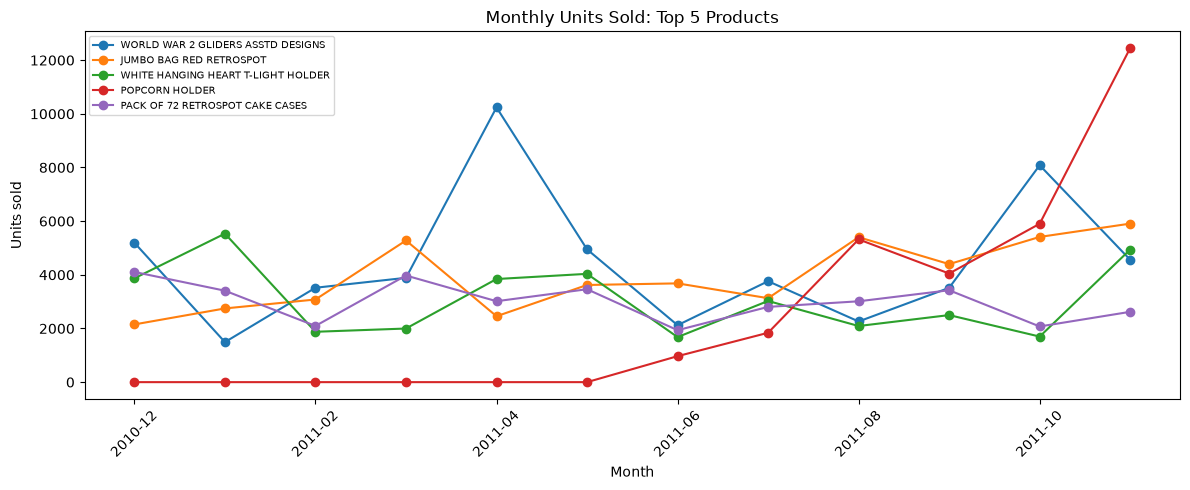

Description
WHITE HANGING HEART T-LIGHT HOLDER     -24.7
PACK OF 72 RETROSPOT CAKE CASES        -20.9
ASSORTED COLOURS SILK FAN              -19.4
WORLD WAR 2 GLIDERS ASSTD DESIGNS      -17.0
PACK OF 60 PINK PAISLEY CAKE CASES     -15.1
PACK OF 12 LONDON TISSUES               -7.1
VICTORIAN GLASS HANGING T-LIGHT          6.6
BROCADE RING PURSE                       9.5
MINI PAINT SET VINTAGE                  26.7
JUMBO BAG RED RETROSPOT                 44.5
ASSORTED COLOUR BIRD ORNAMENT           49.2
JUMBO BAG PINK POLKADOT                 79.6
RED  HARMONICA IN BOX                   90.2
RABBIT NIGHT LIGHT                    2139.4
POPCORN HOLDER                           inf
dtype: float64


In [18]:
top15 = df_clean.groupby('Description')['Quantity'].sum().nlargest(15).index

# Exclude 2011-12 because it is an incomplete month (data ends 9 Dec 2011)
m = df_clean[(df_clean['Description'].isin(top15)) & (df_clean['YearMonth'] != '2011-12')]
pivot = m.pivot_table(index='YearMonth', columns='Description', values='Quantity', aggfunc='sum').fillna(0)

# Monthly trend for the top 5 products
pivot[list(top15[:5])].plot(figsize=(12, 5), marker='o')
plt.title("Monthly Units Sold: Top 5 Products")
plt.xlabel("Month")
plt.ylabel("Units sold")
plt.xticks(rotation=45)
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()

# Average monthly units: first 6 months vs last 6 months
early = pivot.loc['2010-12':'2011-05'].mean()
late = pivot.loc['2011-06':'2011-11'].mean()
change = ((late - early) / early * 100).round(1).sort_values()
print(change)

# Insights, Recommendations and Limitations

## Data cleaning decisions
- Original data: 541,909 rows, 8 columns. After cleaning about 522,500 rows remain.
- Removed 5,268 exact duplicate rows.
- Moved cancelled invoices (InvoiceNo starting with "C", 9,288 rows) into a separate table for return analysis.
- Removed rows with zero or negative price or quantity (bad entries and adjustments).
- Removed non-product entries (postage, fees, manual adjustments), identified by StockCode not starting with 5 digits.
- Removed rows with missing Description.
- Kept rows with missing CustomerID (about 25% of the data) because they are real sales, but used only rows with CustomerID for customer-level analysis.
- Removed two invoices (541431 and 581483) with 74,215 and 80,995 units, because each was cancelled later. This reduced revenue by about 245,000.
- Other large orders were kept because they can be genuine wholesale sales.

## Final dataset
- Revenue: 10,001,167 | Customers (with ID): 4,333 | Invoices: 19,771 | Products: 3,899 | Countries: 38

## Key insights
1. **Revenue is seasonal.** Monthly revenue stays at 5 to 7.7 lakh from Jan to Aug 2011, then rises sharply to a peak in November 2011 (1,452,113), about 2.9 times the weakest full month (February 2011, 507,783). December 2011 looks low only because the data ends on 9 December.
2. **The business depends heavily on the United Kingdom.** The UK gives 84.8% of revenue. The other 37 countries together give 15.2%.
3. **A small group of customers drives revenue.** The top 20% of customers (with a CustomerID) give 73.9% of revenue, close to the 80/20 rule.
4. **Top products by revenue and by units are different.** Regency Cakestand 3 Tier leads in revenue, while World War 2 Gliders Asstd Designs (54,951 units), Jumbo Bag Red Retrospot (48,371) and White Hanging Heart T-Light Holder (37,872) lead in units.
5. **Order value is skewed.** Average order value is 505.85 but the median is 302.20, so a few very large orders pull the average up.
6. **About 14.81% of invoices are cancelled** (3,836 of 25,900).
7. **Orders follow office hours.** Thursday is the busiest day (4,209 orders), Sunday the weakest (2,203), and there are no Saturday orders. Orders peak at 12:00 (3,204 orders).
8. **Price and quantity move in opposite directions.** Bulk orders are mostly for cheap products, and expensive items sell in small quantities.
9. **Customer spend is linked to items bought** (correlation 0.92) and, more weakly, to the number of orders (0.58).
10. **Demand is changing.** White Hanging Heart T-Light Holder (-24.7%), Pack of 72 Retrospot Cake Cases (-20.9%) and Assorted Colours Silk Fan (-19.4%) are declining, while Jumbo Bag Pink Polkadot (+79.6%) and Red Harmonica in Box (+90.2%) are growing. Popcorn Holder and Rabbit Night Light look like late launches, so their growth percentages are not meaningful.

## Business recommendations
- Prepare stock and marketing for September to November, when demand rises most.
- Reduce dependence on the UK with campaigns and shipping offers in Netherlands, EIRE, Germany and France.
- Give loyalty offers to the top customers, since they bring most of the revenue.
- Investigate the high cancellation rate (stock, shipping or entry errors).
- Send promotions on Tuesday to Thursday during office hours.
- Promote or bundle products with falling demand and keep stock of rising products.

## Limitations
- The data covers only one year (Dec 2010 to 9 Dec 2011), so seasonality cannot be confirmed across years.
- About 25% of rows have no CustomerID, so customer insights cover only the remaining customers.
- The reason for the peak in November (festive season) is an assumption and is not proved by the data.
- There are no Saturday orders in the dataset, which may be a data collection issue.